# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas
## Clasificación binaria de células sanguíneas con BloodMNIST

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

En esta versión trabajaremos con **BloodMNIST**, un dataset de imágenes de células individuales de sangre periférica (glóbulos blancos, glóbulos rojos y plaquetas), disponible dentro del paquete `medmnist`.

**Importante:** BloodMNIST en su versión original tiene **8 clases** (distintos tipos de célula). Para este ejercicio, y siguiendo la misma lógica binaria que usamos con PneumoniaMNIST, vamos a **quedarnos solo con 2 de esas 8 clases** y las vamos a tratar como un problema de clasificación binaria:

- **Clase 0:** `neutrophil` (neutrófilo) — el tipo de glóbulo blanco más abundante en sangre.
- **Clase 1:** `lymphocyte` (linfocito) — otro tipo de glóbulo blanco, encargado de la respuesta inmune específica.

Es decir, así como antes teníamos `Clase 0: Normal (sin neumonía)` y `Clase 1: Neumonía`, ahora tendremos `Clase 0: Neutrófilo` y `Clase 1: Linfocito`. La diferencia es que aquí ambas clases representan células normales (no hay una clase "enferma"), pero el problema de aprendizaje sigue siendo el mismo: **una red que debe aprender a distinguir entre dos categorías a partir de una imagen**.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones (bordes, manchas de color, texturas de la membrana celular, forma del núcleo, etc.).

En el caso de BloodMNIST, estas texturas y formas son justamente lo que un especialista de laboratorio observa al microscopio para diferenciar un neutrófilo de un linfocito: el tamaño relativo del núcleo, su forma (lobulada vs. redonda) y la cantidad de citoplasma visible. Una CNN bien entrenada aprende a fijarse en pistas visuales parecidas.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

### 2.1. Activar GPU en el entorno de ejecución (Google Colab)

Antes de instalar nada y de correr las celdas, conviene **cambiar el entorno de ejecución a GPU** para que el entrenamiento sea mucho más rápido (una CNN entrenando sobre miles de imágenes en CPU puede tardar varias veces más que en GPU).


In [4]:
import torch

# Si se activa la GPU correctamente en el paso anterior, aquí debería aparecer "cuda".
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Entorno de Ejecuciòn:", device)


Entorno de Ejecuciòn: cuda


In [5]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (BloodMNIST) y reducirlo a 2 clases

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar. En este caso usaremos **BloodMNIST**.

Características del dataset **BloodMNIST** (versión completa, tal como viene en `medmnist`):

- **Entrada:** imágenes a color (RGB) de células individuales de sangre periférica, de tamaño 28x28 píxeles y 3 canales de color.
- **Etiquetas originales:** 8 clases de tipos de célula (`basophil`, `eosinophil`, `erythroblast`, `immature granulocytes`, `lymphocyte`, `monocyte`, `neutrophil`, `platelet`).
- **Particiones:** train/val/test ya vienen definidas por `medmnist`.

Como se explicó en la portada, para este ejercicio **no vamos a usar las 8 clases**: nos quedaremos solo con `neutrophil` y `lymphocyte`, y las vamos a remapear a las etiquetas `0` y `1` respectivamente, igual que se hacía con `Normal=0` / `Neumonía=1` en PneumoniaMNIST.


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO


data_flag = "bloodmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'BloodMNIST',
 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1',
 'MD5': '7053d0359d879ad8a5505303e11de1dc',
 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1',
 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b',
 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1',
 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c',
 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist

In [7]:
# Transform básico: solo convertimos la imagen (PIL) a tensor de PyTorch.
# A diferencia de PneumoniaMNIST (1 canal, escala de grises), BloodMNIST entrega
# imágenes a color, por lo que el tensor resultante tendrá forma (3, 28, 28).
transform_basic = T.Compose([
    T.ToTensor()
])

# Cargamos el dataset COMPLETO (8 clases) para cada partición.
train_dataset_full = DataClass(split="train", transform=transform_basic, download=True)
val_dataset_full = DataClass(split="val", transform=transform_basic, download=True)
test_dataset_full = DataClass(split="test", transform=transform_basic, download=True)

print("Clases originales de BloodMNIST:", info["label"])
print(f"Tamaño original -> train: {len(train_dataset_full)}, val: {len(val_dataset_full)}, test: {len(test_dataset_full)}")


100%|██████████| 35.5M/35.5M [00:41<00:00, 850kB/s] 


Clases originales de BloodMNIST: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Tamaño original -> train: 11959, val: 1712, test: 3421


In [8]:
class BinaryClassDataset(Dataset):
    """
    Envoltorio (wrapper) que convierte el dataset original de BloodMNIST (8 clases)
    en un problema binario, quedándonos únicamente con las imágenes de dos tipos
    de célula y remapeando sus etiquetas a 0 y 1.

    Esto es análogo a lo que ya veníamos haciendo con PneumoniaMNIST
    (Clase 0: Normal, Clase 1: Neumonía), solo que aquí las dos clases
    son dos tipos distintos de glóbulo blanco.
    """

    def __init__(self, base_dataset, class_map):
        self.base_dataset = base_dataset
        # class_map: diccionario {etiqueta_original: etiqueta_nueva}, por ejemplo {6: 0, 4: 1}
        self.class_map = class_map

        # base_dataset.labels es un arreglo numpy de forma (N, 1) con la etiqueta
        # original de cada imagen. Filtramos solo los índices que nos interesan.
        self.indices = [
            i for i in range(len(base_dataset))
            if int(base_dataset.labels[i][0]) in class_map
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        x, y = self.base_dataset[real_idx]

        original_label = int(y[0]) if hasattr(y, "__len__") else int(y)
        new_label = self.class_map[original_label]

        # Devolvemos la etiqueta con forma (1,), igual que el formato original
        # de medmnist, para no tener que tocar el resto del código de entrenamiento.
        return x, torch.tensor([new_label], dtype=torch.long)


# Elegimos las dos clases originales de BloodMNIST que vamos a usar.
# Revisando info["label"] -> {"0": "basophil", "1": "eosinophil", "2": "erythroblast",
# "3": "immature granulocytes", "4": "lymphocyte", "5": "monocyte",
# "6": "neutrophil", "7": "platelet"}
class_map = {6: 0, 4: 1}   # neutrophil -> 0 ,  lymphocyte -> 1
class_names = ["neutrophil", "lymphocyte"]

train_dataset = BinaryClassDataset(train_dataset_full, class_map)
val_dataset = BinaryClassDataset(val_dataset_full, class_map)
test_dataset = BinaryClassDataset(test_dataset_full, class_map)

print("Clase 0:", class_names[0], " | Clase 1:", class_names[1])
print(f"Tamaño del subconjunto binario -> train: {len(train_dataset)}, "
      f"val: {len(val_dataset)}, test: {len(test_dataset)}")


Clase 0: neutrophil  | Clase 1: lymphocyte
Tamaño del subconjunto binario -> train: 3179, val: 455, test: 909


### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.

Como BloodMNIST es a color, ajustamos la función de visualización: en vez de mostrar la imagen con `cmap="gray"` (que era correcto para radiografías en escala de grises), reordenamos el tensor de `(canales, alto, ancho)` a `(alto, ancho, canales)` para que `matplotlib` la despliegue con sus colores reales.


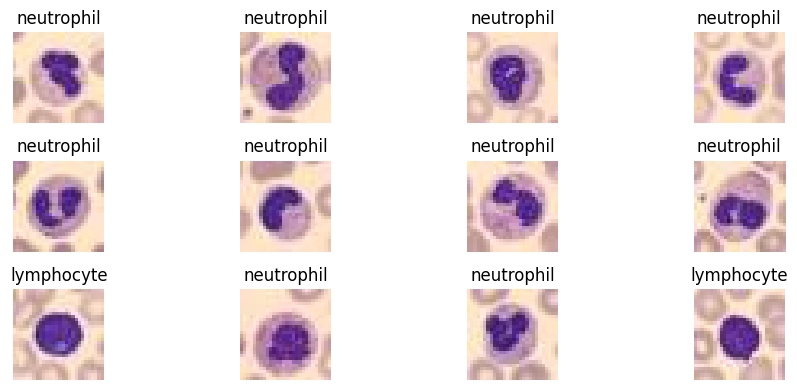

In [9]:
def show_batch(dataset, n=12, class_names=None):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)

        # x tiene forma (3, 28, 28) -> la pasamos a (28, 28, 3) para poder mostrarla a color.
        img = x.permute(1, 2, 0).numpy()
        plt.imshow(img)

        label_idx = int(y.item())
        label_txt = class_names[label_idx] if class_names is not None else str(label_idx)
        plt.title(label_txt)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12, class_names=class_names)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe (recuerda el paso 2.1: si activaste la GPU en Colab, aquí debería seguir apareciendo `cuda`).


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [11]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# El primer valor del shape nos dirá el tamaño del batch, y el segundo, tercero y cuarto
# corresponden a (canales, alto, ancho). Aquí deberíamos ver 3 canales (RGB), no 1.
next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.

**Nota sobre canales de entrada:** en PneumoniaMNIST usábamos `nn.Conv2d(1, 16, ...)` porque las radiografías son en escala de grises (1 canal). Como BloodMNIST es a color, la primera convolución debe recibir **3 canales** de entrada. Para no dejarlo mal en el código, tomamos ese número directamente de `info["n_channels"]`.


In [12]:
import torch.nn as nn
import torch.nn.functional as F

# Como ya filtramos el dataset a 2 clases, fijamos num_classes = 2 manualmente
# (en vez de usar len(info["label"]), que seguiría devolviendo 8).
num_classes = 2
in_channels = info["n_channels"]   # 3 en el caso de BloodMNIST (RGB)

print(f"num_classes = {num_classes} | in_channels = {in_channels}")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes, in_channels=in_channels).to(device)
model_scratch


num_classes = 2 | in_channels = 3


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Además, para poder graficar la pérdida de **entrenamiento junto con la de validación** (y así detectar sobreajuste, tal como hicimos en los notebooks anteriores con Keras), la función `evaluate` ahora también calcula y devuelve la pérdida (`loss`) sobre el conjunto que se le pase, no solo accuracy y AUC.


In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """
    Evalúa el modelo sobre 'loader'.
    Si se le pasa 'criterion', también calcula la pérdida promedio (val_loss),
    para poder compararla con la pérdida de entrenamiento en las gráficas.
    """
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        if criterion is not None:
            loss = criterion(logits, y)
            losses.append(loss.item())

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    avg_loss = float(np.mean(losses)) if losses else None

    return acc, auc, avg_loss, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.

Guardamos en `history_scratch` tanto la pérdida de entrenamiento (`train_loss`) como la de validación (`val_loss`), además de `val_acc` y `val_auc`, para poder graficar ambas curvas de pérdida juntas más adelante.


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_scratch, val_loader, criterion)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5989 | val_loss=0.5799 | val_acc=0.7319 | val_auc=0.4045
Epoch 02 | train_loss=0.5827 | val_loss=0.5771 | val_acc=0.7319 | val_auc=0.5654
Epoch 03 | train_loss=0.5812 | val_loss=0.5733 | val_acc=0.7319 | val_auc=0.8564
Epoch 04 | train_loss=0.5789 | val_loss=0.5671 | val_acc=0.7319 | val_auc=0.9760
Epoch 05 | train_loss=0.5723 | val_loss=0.5655 | val_acc=0.7319 | val_auc=0.9957
Epoch 06 | train_loss=0.5561 | val_loss=0.5385 | val_acc=0.7319 | val_auc=0.9710
Epoch 07 | train_loss=0.5247 | val_loss=0.4830 | val_acc=0.7341 | val_auc=0.9643
Epoch 08 | train_loss=0.4502 | val_loss=0.3740 | val_acc=0.8571 | val_auc=0.9702


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste. A diferencia de la versión anterior, ahora la gráfica de pérdida incluye **tanto la curva de entrenamiento como la de validación** en el mismo gráfico: si la pérdida de entrenamiento sigue bajando mientras la de validación se estanca o sube, es una señal clara de sobreajuste (el mismo patrón que vimos antes con los modelos de Keras/IMDB).


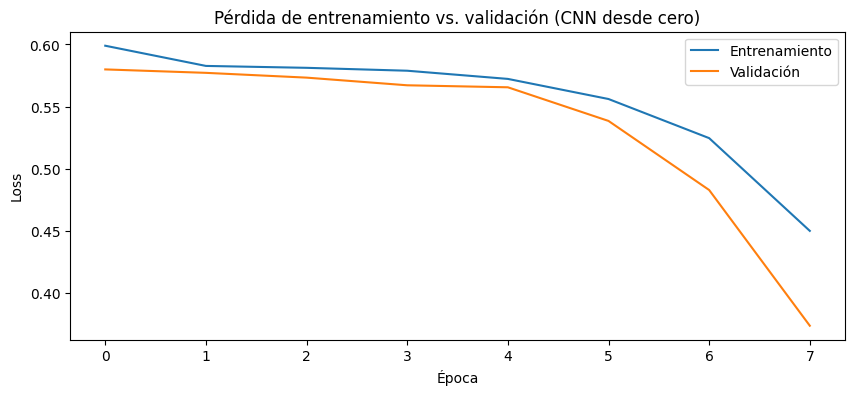

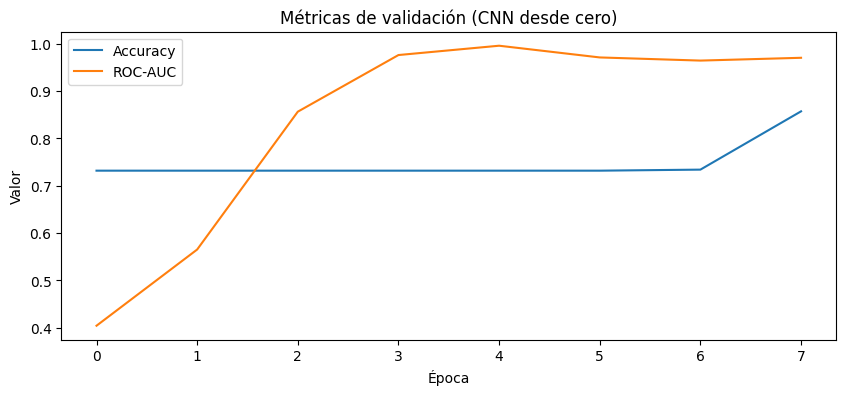

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Entrenamiento")
plt.plot(history_scratch["val_loss"], label="Validación")
plt.title("Pérdida de entrenamiento vs. validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [16]:
test_acc, test_auc, test_loss, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test loss:     {test_loss:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8548
Test ROC-AUC:  0.9701
Test loss:     0.3798

              precision    recall  f1-score   support

  neutrophil     0.8346    1.0000    0.9098       666
  lymphocyte     1.0000    0.4568    0.6271       243

    accuracy                         0.8548       909
   macro avg     0.9173    0.7284    0.7685       909
weighted avg     0.8788    0.8548    0.8343       909



array([[666,   0],
       [132, 111]])

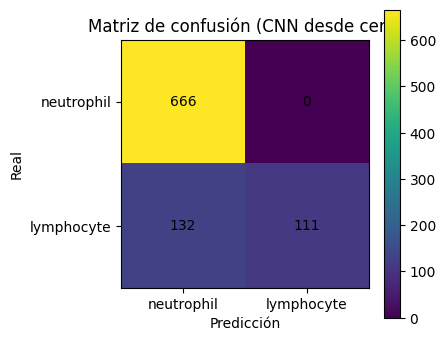

In [17]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Para células sueltas bajo el microscopio (como en BloodMNIST), volteos horizontales/verticales suelen ser válidos, ya que no existe una "orientación correcta" de la célula dentro del campo visual (a diferencia de una radiografía de tórax, donde voltear la imagen sí podría ser problemático).

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [18]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

# Igual que antes, aplicamos el aumento sobre el dataset COMPLETO y luego lo filtramos
# a nuestras 2 clases con el mismo wrapper.
train_dataset_aug_full = DataClass(split="train", transform=transform_aug, download=True)
train_dataset_aug = BinaryClassDataset(train_dataset_aug_full, class_map)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [19]:
model_aug = SimpleCNN(num_classes=num_classes, in_channels=in_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_aug, val_loader, criterion)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.6019 | val_loss=0.5823 | val_acc=0.7319 | val_auc=0.3356
Epoch 02 | train_loss=0.5858 | val_loss=0.5802 | val_acc=0.7319 | val_auc=0.3734
Epoch 03 | train_loss=0.5850 | val_loss=0.5805 | val_acc=0.7319 | val_auc=0.4105
Epoch 04 | train_loss=0.5826 | val_loss=0.5778 | val_acc=0.7319 | val_auc=0.5060
Epoch 05 | train_loss=0.5806 | val_loss=0.5749 | val_acc=0.7319 | val_auc=0.7056
Epoch 06 | train_loss=0.5785 | val_loss=0.5715 | val_acc=0.7319 | val_auc=0.8943


### 6.1. Comparación rápida

In [20]:
test_acc_aug, test_auc_aug, test_loss_aug, _, _, _ = evaluate(model_aug, test_loader, criterion)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8548 | test_auc=0.9701
Con augmentation  | test_acc=0.7327 | test_auc=0.9078


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises (no es el caso aquí).
- El dominio (microscopía celular) es distinto al de fotos naturales, que es con lo que se entrenó originalmente ImageNet.

**Diferencia importante frente a PneumoniaMNIST:** como esas radiografías eran en 1 canal (escala de grises), había que "triplicar" el canal con `T.Lambda(lambda x: x.repeat(3, 1, 1))` para simular una imagen RGB y así poder usar ResNet18 (que espera 3 canales). **BloodMNIST ya es a color (3 canales)**, así que ese truco ya no es necesario: simplemente redimensionamos la imagen a 224x224.


In [21]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
    # Ya no hace falta T.Lambda(lambda x: x.repeat(3, 1, 1)): BloodMNIST ya tiene 3 canales.
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

train_dataset_tl_full = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl_full = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl_full = DataClass(split="test", transform=transform_tl_eval, download=True)

train_dataset_tl = BinaryClassDataset(train_dataset_tl_full, class_map)
val_dataset_tl = BinaryClassDataset(val_dataset_tl_full, class_map)
test_dataset_tl = BinaryClassDataset(test_dataset_tl_full, class_map)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Debería mostrar (batch, 3, 224, 224) para las imágenes.
next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [22]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.4278 | val_loss=0.2639 | val_acc=0.9648 | val_auc=0.9947
Stage1 Epoch 02 | train_loss=0.1956 | val_loss=0.1421 | val_acc=0.9736 | val_auc=0.9974
Stage1 Epoch 03 | train_loss=0.1426 | val_loss=0.1049 | val_acc=0.9802 | val_auc=0.9978
Stage1 Epoch 04 | train_loss=0.1128 | val_loss=0.0884 | val_acc=0.9802 | val_auc=0.9978


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [24]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [25]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.0210 | val_loss=0.0025 | val_acc=0.9978 | val_auc=1.0000
Stage2 Epoch 02 | train_loss=0.0072 | val_loss=0.0009 | val_acc=1.0000 | val_auc=1.0000
Stage2 Epoch 03 | train_loss=0.0024 | val_loss=0.0011 | val_acc=1.0000 | val_auc=1.0000
Stage2 Epoch 04 | train_loss=0.0050 | val_loss=0.0003 | val_acc=1.0000 | val_auc=1.0000


### 7.2.1. Curva de entrenamiento vs. validación (transfer learning)

Igual que en la CNN desde cero, graficamos la pérdida de entrenamiento junto con la de validación, esta vez uniendo ambas etapas (congelado + fine-tuning) para ver la evolución completa.


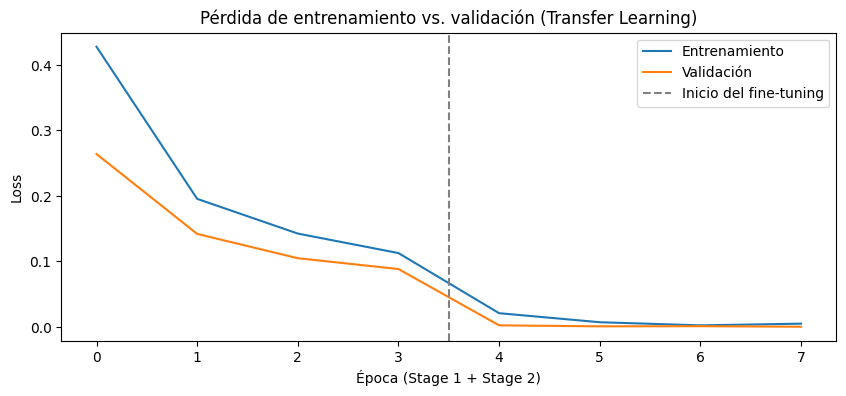

In [26]:
train_loss_tl = history_tl_stage1["train_loss"] + history_tl_stage2["train_loss"]
val_loss_tl = history_tl_stage1["val_loss"] + history_tl_stage2["val_loss"]

plt.figure(figsize=(10, 4))
plt.plot(train_loss_tl, label="Entrenamiento")
plt.plot(val_loss_tl, label="Validación")
plt.axvline(x=len(history_tl_stage1["train_loss"]) - 0.5, color="gray", linestyle="--",
            label="Inicio del fine-tuning")
plt.title("Pérdida de entrenamiento vs. validación (Transfer Learning)")
plt.xlabel("Época (Stage 1 + Stage 2)")
plt.ylabel("Loss")
plt.legend()
plt.show()


### 7.3. Evaluación en test del modelo con transfer learning

In [27]:
test_acc_tl, test_auc_tl, test_loss_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl, criterion)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f} | test_loss={test_loss_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.9967 | test_auc=1.0000 | test_loss=0.0203

              precision    recall  f1-score   support

  neutrophil     1.0000    0.9955    0.9977       666
  lymphocyte     0.9878    1.0000    0.9939       243

    accuracy                         0.9967       909
   macro avg     0.9939    0.9977    0.9958       909
weighted avg     0.9967    0.9967    0.9967       909



array([[663,   3],
       [  0, 243]])

### 7.4. Comparación global (resumen)

In [28]:
print("Resumen de resultados en test (BloodMNIST: neutrophil vs. lymphocyte)")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test (BloodMNIST: neutrophil vs. lymphocyte)
CNN desde cero (sin aug)   | acc=0.8548 | auc=0.9701
CNN desde cero (con aug)   | acc=0.7327 | auc=0.9078
Transfer learning (ResNet) | acc=0.9967 | auc=1.0000


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [29]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


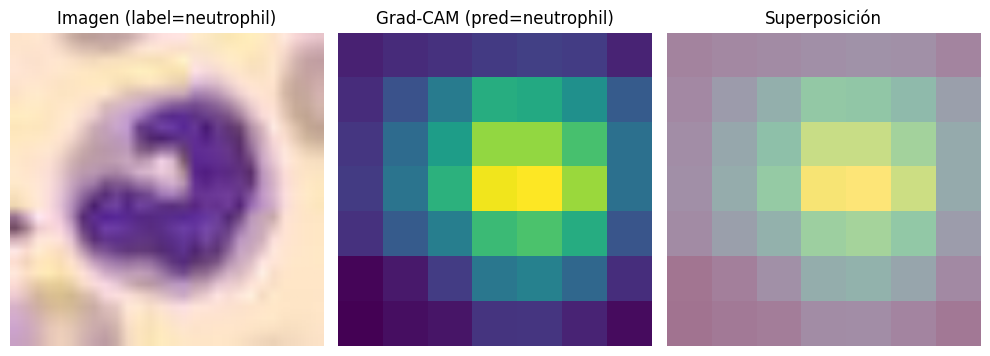

In [30]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

# x tiene forma (3, 224, 224); la pasamos a (224, 224, 3) para mostrarla a color,
# a diferencia de PneumoniaMNIST donde usábamos x[0] con cmap="gray" (1 solo canal).
img = x.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (label={class_names[int(y.item())]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={class_names[pred_class]})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos de cada clase.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global entre clases.

3) Cuidado con sesgos, por ejemplo en el caso de BloodMNIST:
- Diferencias en el proceso de tinción de las muestras según el laboratorio.
- Diferencias entre el equipo de microscopía/cámara usado para capturar las imágenes.
- Variabilidad entre poblaciones de pacientes (edad, condición clínica, etc.).

4) Al reducir un problema multiclase (8 clases) a binario (2 clases), como hicimos aquí, ten en cuenta que estás **descartando información**: en un caso real, probablemente quieras evaluar si el modelo también podría confundir una de tus 2 clases con alguna de las 6 clases que dejaste fuera.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [31]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/bloodmnist_cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/bloodmnist_cnn_aug.pth")
torch.save(resnet.state_dict(), "models/bloodmnist_resnet_transfer.pth")

["models/bloodmnist_cnn_scratch.pth", "models/bloodmnist_cnn_aug.pth", "models/bloodmnist_resnet_transfer.pth"]


['models/bloodmnist_cnn_scratch.pth',
 'models/bloodmnist_cnn_aug.pth',
 'models/bloodmnist_resnet_transfer.pth']

## 11. Ejercicios sugeridos

A continuación se profundiza en los temas que proponen estos ejercicios, en el contexto de BloodMNIST (neutrophil vs. lymphocyte).

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


### 11.1. Arquitectura de la CNN: BatchNorm, Dropout y más filtros

Estas son tres de las modificaciones más comunes para mejorar una CNN base:

- **`BatchNorm2d`**: normaliza las activaciones de cada mini-lote después de cada convolución. Esto suele acelerar la convergencia y hacer que el entrenamiento sea menos sensible a la elección del learning rate.
- **`Dropout`**: apaga aleatoriamente una fracción de las neuronas o canales durante el entrenamiento, obligando a la red a no depender demasiado de unas pocas unidades. Es el mismo principio que se vio en los notebooks anteriores de Keras, donde se alternaba `Dense` + `Dropout(0.5)`; aquí se traduce en alternar bloques convolucionales con `Dropout2d`, más un `Dropout` final antes de la capa de clasificación.
- **Más filtros por bloque**: pasar, por ejemplo, de 16/32/64 a 32/64/128 filtros le da a la red más capacidad para representar patrones, aunque también aumenta la cantidad de parámetros y el tiempo de entrenamiento.

La clase `ImprovedCNN` reúne estos tres cambios sobre la arquitectura base (`SimpleCNN`).


In [32]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),   # dropout leve tras el primer bloque

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),   # un poco más de dropout en el segundo bloque

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),   # dropout más fuerte antes de la capa final, como en Keras
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_improved = ImprovedCNN(num_classes=num_classes, in_channels=in_channels).to(device)
model_improved


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.3, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_improved.parameters(), lr=1e-3)

epochs = 8
history_improved = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_improved, train_loader, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_improved, val_loader, criterion)

    history_improved["train_loss"].append(train_loss)
    history_improved["val_loss"].append(val_loss)
    history_improved["val_acc"].append(val_acc)
    history_improved["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5467 | val_loss=0.6484 | val_acc=0.7319 | val_auc=0.9069
Epoch 02 | train_loss=0.3959 | val_loss=0.4507 | val_acc=0.7385 | val_auc=0.9782
Epoch 03 | train_loss=0.2998 | val_loss=0.3782 | val_acc=0.7802 | val_auc=0.9927
Epoch 04 | train_loss=0.2265 | val_loss=0.3425 | val_acc=0.8066 | val_auc=0.9976
Epoch 05 | train_loss=0.1891 | val_loss=0.0872 | val_acc=0.9780 | val_auc=0.9985
Epoch 06 | train_loss=0.1495 | val_loss=0.0583 | val_acc=0.9846 | val_auc=0.9994
Epoch 07 | train_loss=0.1303 | val_loss=0.0571 | val_acc=0.9846 | val_auc=0.9995
Epoch 08 | train_loss=0.1189 | val_loss=0.0469 | val_acc=0.9912 | val_auc=0.9996


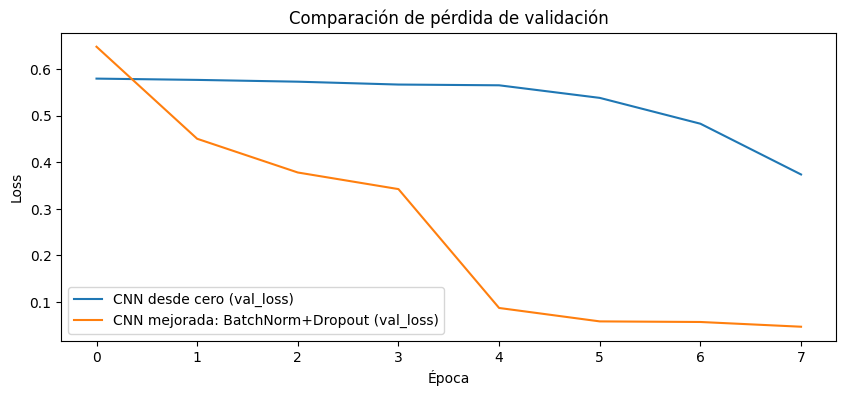

CNN desde cero              | test_acc=0.8548 | test_auc=0.9701
CNN mejorada (BN + Dropout) | test_acc=0.9923 | test_auc=0.9990


In [34]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_loss"], label="CNN desde cero (val_loss)")
plt.plot(history_improved["val_loss"], label="CNN mejorada: BatchNorm+Dropout (val_loss)")
plt.title("Comparación de pérdida de validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_acc_improved, test_auc_improved, test_loss_improved, _, _, _ = evaluate(model_improved, test_loader, criterion)
print(f"CNN desde cero              | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"CNN mejorada (BN + Dropout) | test_acc={test_acc_improved:.4f} | test_auc={test_auc_improved:.4f}")


### 11.2. Learning rate y scheduler

El *learning rate* controla qué tan grandes son los ajustes que el optimizador aplica a los pesos en cada paso. Mantenerlo fijo durante todo el entrenamiento no siempre es lo ideal: un valor más alto ayuda a avanzar rápido al principio, pero hacia el final puede hacer que los pesos oscilen en vez de asentarse en un buen mínimo.

Un **scheduler** ajusta el learning rate automáticamente durante el entrenamiento. `ReduceLROnPlateau`, en particular, reduce el learning rate cuando una métrica de referencia (aquí, la pérdida de validación) deja de mejorar durante un número determinado de épocas (`patience`), lo que suele ayudar a que el modelo termine de afinarse en las últimas épocas.


In [35]:
model_lr = ImprovedCNN(num_classes=num_classes, in_channels=in_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lr.parameters(), lr=1e-3)

# El scheduler observa 'val_loss': si no mejora durante 'patience' épocas seguidas,
# multiplica el learning rate por 'factor' (lo reduce a la mitad).
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

epochs = 10
history_lr = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_lr, train_loader, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_lr, val_loader, criterion)

    # El scheduler decide si baja el learning rate en base a la pérdida de validación.
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history_lr["train_loss"].append(train_loss)
    history_lr["val_loss"].append(val_loss)
    history_lr["val_acc"].append(val_acc)
    history_lr["val_auc"].append(val_auc)
    history_lr["lr"].append(current_lr)

    print(f"Epoch {epoch:02d} | lr={current_lr:.6f} | train_loss={train_loss:.4f} "
          f"| val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | lr=0.001000 | train_loss=0.5161 | val_loss=0.9970 | val_acc=0.7319 | val_auc=0.9117
Epoch 02 | lr=0.001000 | train_loss=0.3621 | val_loss=0.9935 | val_acc=0.7319 | val_auc=0.9820
Epoch 03 | lr=0.001000 | train_loss=0.2704 | val_loss=0.6540 | val_acc=0.7363 | val_auc=0.9956
Epoch 04 | lr=0.001000 | train_loss=0.2049 | val_loss=0.1332 | val_acc=0.9429 | val_auc=0.9976
Epoch 05 | lr=0.001000 | train_loss=0.1657 | val_loss=0.0623 | val_acc=0.9846 | val_auc=0.9994
Epoch 06 | lr=0.001000 | train_loss=0.1498 | val_loss=0.3951 | val_acc=0.8022 | val_auc=0.9991
Epoch 07 | lr=0.001000 | train_loss=0.1271 | val_loss=0.1763 | val_acc=0.9143 | val_auc=0.9993
Epoch 08 | lr=0.001000 | train_loss=0.1133 | val_loss=0.0601 | val_acc=0.9868 | val_auc=0.9998
Epoch 09 | lr=0.001000 | train_loss=0.0913 | val_loss=0.0390 | val_acc=0.9912 | val_auc=0.9998
Epoch 10 | lr=0.001000 | train_loss=0.0855 | val_loss=0.0314 | val_acc=0.9912 | val_auc=0.9998


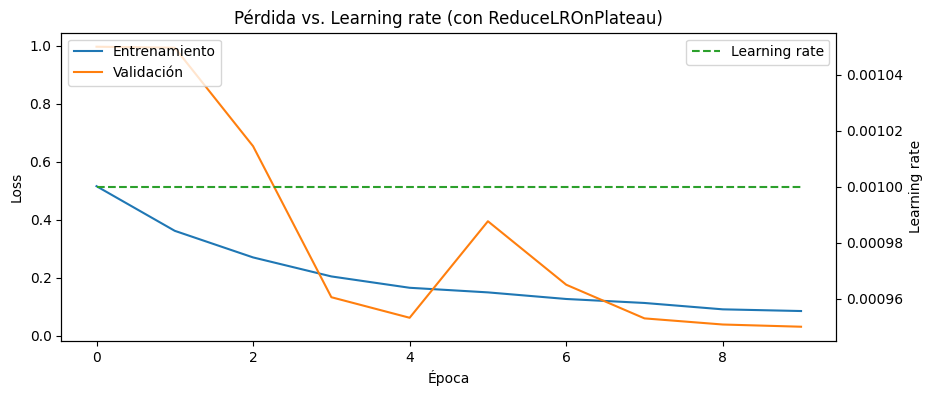

CNN mejorada + scheduler | test_acc=0.9901 | test_auc=0.9989


In [36]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(history_lr["train_loss"], label="Entrenamiento", color="tab:blue")
ax1.plot(history_lr["val_loss"], label="Validación", color="tab:orange")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper left")

# Eje secundario para ver cómo baja el learning rate con el scheduler.
ax2 = ax1.twinx()
ax2.plot(history_lr["lr"], label="Learning rate", color="tab:green", linestyle="--")
ax2.set_ylabel("Learning rate")
ax2.legend(loc="upper right")

plt.title("Pérdida vs. Learning rate (con ReduceLROnPlateau)")
plt.show()

test_acc_lr, test_auc_lr, test_loss_lr, _, _, _ = evaluate(model_lr, test_loader, criterion)
print(f"CNN mejorada + scheduler | test_acc={test_acc_lr:.4f} | test_auc={test_auc_lr:.4f}")


### 11.3. Impacto de distintos aumentos de datos

El aumento "moderado" usado en la sección 6 (rotación ± 10° y traslación leve) es solo un punto dentro de un rango mucho más amplio de transformaciones posibles. Aumentos más agresivos —como el volteo horizontal, el volteo vertical o variaciones de brillo/contraste (`ColorJitter`)— pueden aportar más o menos según el tipo de imagen: para una célula suelta bajo el microscopio, como en BloodMNIST, voltear la imagen no cambia su interpretación biológica (no hay una "orientación correcta"), a diferencia de, por ejemplo, una radiografía de tórax, donde ciertas transformaciones sí podrían ser problemáticas.


In [37]:
transform_aug_v2 = T.Compose([
    T.RandomRotation(degrees=20),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor()
])

train_dataset_aug_v2_full = DataClass(split="train", transform=transform_aug_v2, download=True)
train_dataset_aug_v2 = BinaryClassDataset(train_dataset_aug_v2_full, class_map)
train_loader_aug_v2 = DataLoader(train_dataset_aug_v2, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

model_aug_v2 = SimpleCNN(num_classes=num_classes, in_channels=in_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug_v2.parameters(), lr=1e-3)

epochs = 6
history_aug_v2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug_v2, train_loader_aug_v2, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_aug_v2, val_loader, criterion)

    history_aug_v2["train_loss"].append(train_loss)
    history_aug_v2["val_loss"].append(val_loss)
    history_aug_v2["val_acc"].append(val_acc)
    history_aug_v2["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5980 | val_loss=0.5801 | val_acc=0.7319 | val_auc=0.3415
Epoch 02 | train_loss=0.5845 | val_loss=0.5800 | val_acc=0.7319 | val_auc=0.3739
Epoch 03 | train_loss=0.5831 | val_loss=0.5808 | val_acc=0.7319 | val_auc=0.4400
Epoch 04 | train_loss=0.5849 | val_loss=0.5778 | val_acc=0.7319 | val_auc=0.5501
Epoch 05 | train_loss=0.5798 | val_loss=0.5729 | val_acc=0.7319 | val_auc=0.8189
Epoch 06 | train_loss=0.5749 | val_loss=0.5695 | val_acc=0.7319 | val_auc=0.8274


In [38]:
test_acc_aug_v2, test_auc_aug_v2, test_loss_aug_v2, _, _, _ = evaluate(model_aug_v2, test_loader, criterion)

print("Comparación del efecto de distintos aumentos de datos")
print(f"Sin augmentation                     | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Augmentation moderado (rotación+trasl.) | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")
print(f"Augmentation agresivo (+flip+color)     | test_acc={test_acc_aug_v2:.4f} | test_auc={test_auc_aug_v2:.4f}")


Comparación del efecto de distintos aumentos de datos
Sin augmentation                     | test_acc=0.8548 | test_auc=0.9701
Augmentation moderado (rotación+trasl.) | test_acc=0.7327 | test_auc=0.9078
Augmentation agresivo (+flip+color)     | test_acc=0.7327 | test_auc=0.8263


### 11.4. Cambiar el dataset dentro de `medmnist`

`medmnist` agrupa varios datasets médicos bajo una misma interfaz (`INFO`, `DataClass`, particiones de train/val/test ya definidas), lo que en principio permite pasar de un dataset a otro sin reescribir todo el pipeline. Sin embargo, cada dataset tiene particularidades propias que conviene revisar antes de reutilizar el código:

- **Número de canales** (`info["n_channels"]`): algunos datasets son en escala de grises (1 canal, como PneumoniaMNIST) y otros a color (3 canales, como BloodMNIST). Esto afecta directamente la primera capa convolucional y las transformaciones usadas para transfer learning.
- **Número de clases** (`info["label"]`): algunos datasets ya son binarios (como `breastmnist`), mientras que otros tienen varias clases (como `bloodmnist` o `dermamnist`), lo que puede requerir agrupar o seleccionar categorías si se quiere plantear un problema binario.
- **Forma de visualizar las imágenes**: por ejemplo, usar `cmap="gray"` solo tiene sentido cuando la imagen tiene 1 canal; con imágenes a color hay que reordenar los ejes del tensor para mostrarlas correctamente.

Estos son, en general, los puntos que hay que revisar al migrar este tipo de pipeline entre distintos datasets de `medmnist`, como `pneumoniamnist`, `bloodmnist`, `breastmnist` o `dermamnist`.


### 11.5. Calibración de probabilidades y curvas ROC

Un modelo puede tener buena accuracy y, aun así, sus probabilidades pueden estar "mal calibradas": por ejemplo, asignar 90% de confianza a predicciones que en realidad aciertan solo el 70% de las veces. Dos herramientas ayudan a analizar esto:

- **Curva de calibración**: compara la probabilidad predicha por el modelo contra la frecuencia real de aciertos, agrupando las predicciones en bloques (bins). Mientras más cerca esté de la diagonal, mejor calibrado está el modelo.
- **Curva ROC**: muestra el balance entre sensibilidad (recall) y tasa de falsos positivos para distintos umbrales de decisión; el área bajo la curva (ROC-AUC) resume ese balance en un solo número.

Las celdas siguientes calculan ambas métricas sobre las predicciones del modelo con transfer learning (`resnet`) en el conjunto de test.


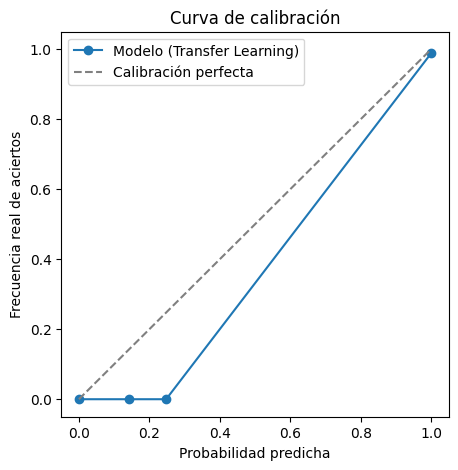

Brier score (más cercano a 0 es mejor): 0.0035


In [39]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc, brier_score_loss

# y_prob_tl y y_true_tl ya los calculamos en la sección 7.3 al evaluar el modelo de transfer learning.
prob_true, prob_pred = calibration_curve(y_true_tl, y_prob_tl, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo (Transfer Learning)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia real de aciertos")
plt.title("Curva de calibración")
plt.legend()
plt.show()

brier = brier_score_loss(y_true_tl, y_prob_tl)
print(f"Brier score (más cercano a 0 es mejor): {brier:.4f}")


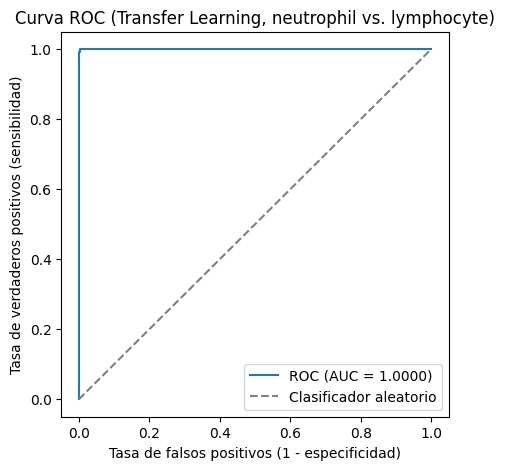

In [40]:
fpr, tpr, thresholds = roc_curve(y_true_tl, y_prob_tl)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC (Transfer Learning, neutrophil vs. lymphocyte)")
plt.legend()
plt.show()


## Conclusión

Este notebook trasladó el flujo de trabajo usado con PneumoniaMNIST hacia **BloodMNIST**, reduciendo un problema de 8 clases a uno binario (`neutrophil` vs. `lymphocyte`), y profundizó en varios temas relevantes para mejorar y entender un modelo de clasificación de imágenes: arquitecturas con BatchNorm y Dropout, ajuste del learning rate mediante schedulers, el efecto de distintos niveles de aumento de datos, las consideraciones al cambiar de dataset dentro de `medmnist`, y el análisis de calibración de probabilidades junto con la curva ROC del modelo con mejor desempeño (transfer learning con ResNet18).
